In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install fastai

In [3]:
!unzip EuroSAT.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/2750/SeaLake/SeaLake_2206.jpg  
  inflating: /content/2750/SeaLake/SeaLake_1313.jpg  
  inflating: /content/2750/SeaLake/SeaLake_263.jpg  
  inflating: /content/2750/SeaLake/SeaLake_967.jpg  
  inflating: /content/2750/SeaLake/SeaLake_515.jpg  
  inflating: /content/2750/SeaLake/SeaLake_1465.jpg  
  inflating: /content/2750/SeaLake/SeaLake_1817.jpg  
  inflating: /content/2750/SeaLake/SeaLake_2902.jpg  
  inflating: /content/2750/SeaLake/SeaLake_2570.jpg  
  inflating: /content/2750/SeaLake/SeaLake_1004.jpg  
  inflating: /content/2750/SeaLake/SeaLake_174.jpg  
  inflating: /content/2750/SeaLake/SeaLake_2111.jpg  
  inflating: /content/2750/SeaLake/SeaLake_2388.jpg  
  inflating: /content/2750/SeaLake/SeaLake_1948.jpg  
  inflating: /content/2750/SeaLake/SeaLake_838.jpg  
  inflating: /content/2750/SeaLake/SeaLake_2738.jpg  
  inflating: /content/2750/SeaLake/SeaLake_1999.jpg  
  inflating: /content/2750/SeaLake/S

In [4]:
!ls /content

2750  EuroSAT.zip  sample_data


In [5]:
!ls /content/2750

AnnualCrop  HerbaceousVegetation  Industrial  PermanentCrop  River
Forest	    Highway		  Pasture     Residential    SeaLake


**Dataset Information**

* Dataset : EuroSAT

* Images : 27,000

* Classes : 10

* Image Size : 64×64

* Type : RGB Satellite Images

In [6]:
#Information Regarding Dataset
import torch
from torchvision import datasets, transforms

# ImageNet normalization values (used by ResNet50)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

dataset = datasets.ImageFolder(
    root="/content/2750",
    transform=transform
)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)

Number of images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


**Why we used RESNET 50**

• Pretrained on ImageNet

• Learns powerful image features

• Reduces training time

• Improves accuracy

• Ideal for transfer learning

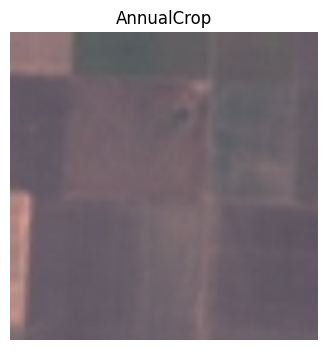

In [7]:
#Sample Image
import matplotlib.pyplot as plt

# Get one sample
image, label = dataset[0]

# Convert tensor back to image for display
image = image.permute(1, 2, 0)

# Undo normalization
image = image * torch.tensor(std) + torch.tensor(mean)
image = image.clamp(0, 1)

plt.figure(figsize=(4,4))
plt.imshow(image)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [8]:
#Data Spliting
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Testing images: {len(test_dataset)}")

Training images: 21600
Validation images: 2700
Testing images: 2700


In [9]:
#Data Load and Split
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 675
Validation batches: 85
Test batches: 85


In [10]:
#Loading ResNet50 and Layer Freeze
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet50
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model.fc)
print(f"Using device: {device}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 81.5MB/s]


Linear(in_features=2048, out_features=10, bias=True)
Using device: cuda


In [11]:
#Preparing the Loss function and Optimizer
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (only train the final layer)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss function and optimizer are ready!")

Loss function and optimizer are ready!


In [12]:
#Epoch and Tranining
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/10] Loss: 0.6178 Accuracy: 82.65%
Epoch [2/10] Loss: 0.3299 Accuracy: 89.77%
Epoch [3/10] Loss: 0.2739 Accuracy: 91.50%
Epoch [4/10] Loss: 0.2378 Accuracy: 92.32%
Epoch [5/10] Loss: 0.2128 Accuracy: 93.27%
Epoch [6/10] Loss: 0.2015 Accuracy: 93.61%
Epoch [7/10] Loss: 0.1860 Accuracy: 94.03%
Epoch [8/10] Loss: 0.1743 Accuracy: 94.41%
Epoch [9/10] Loss: 0.1691 Accuracy: 94.31%
Epoch [10/10] Loss: 0.1613 Accuracy: 94.61%


In [13]:
#Test Accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 93.70%


                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.94      0.94       283
              Forest       0.95      0.98      0.97       339
HerbaceousVegetation       0.93      0.93      0.93       294
             Highway       0.88      0.87      0.87       268
          Industrial       0.96      0.96      0.96       248
             Pasture       0.89      0.92      0.91       167
       PermanentCrop       0.92      0.93      0.93       253
         Residential       0.97      0.99      0.98       289
               River       0.90      0.86      0.88       260
             SeaLake       0.99      0.97      0.98       299

            accuracy                           0.94      2700
           macro avg       0.93      0.93      0.93      2700
        weighted avg       0.94      0.94      0.94      2700



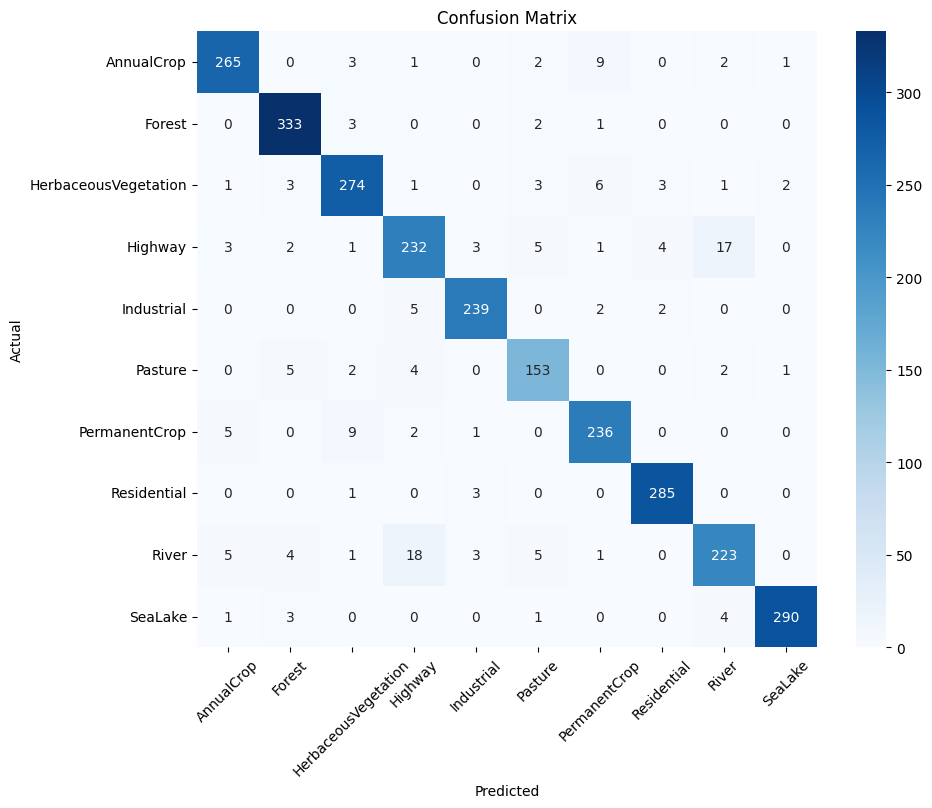

In [14]:
#Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes
))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

**Hyper Parameters**

* Batch Size: 32

* Epochs : 10

* Learning Rate : 0.001

* Optimizer : Adam

* Loss Function : CrossEntropyLoss

* Architecture : ResNet50

* Transfer Learning : Yes

In [15]:
torch.save(model.state_dict(), "eurosat_resnet50.pth")

print("Model saved successfully!")

Model saved successfully!


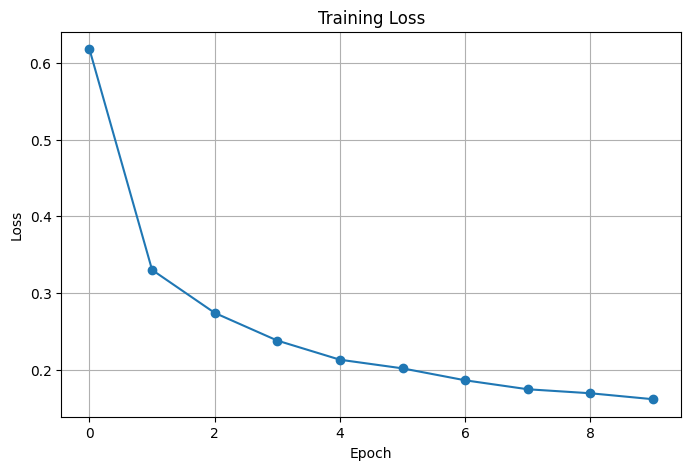

In [16]:
#Visuals of Loss Curve
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

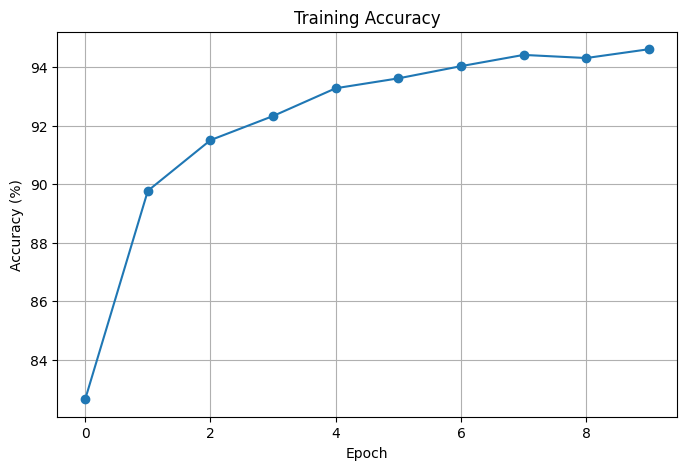

In [17]:
#Visuals of Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

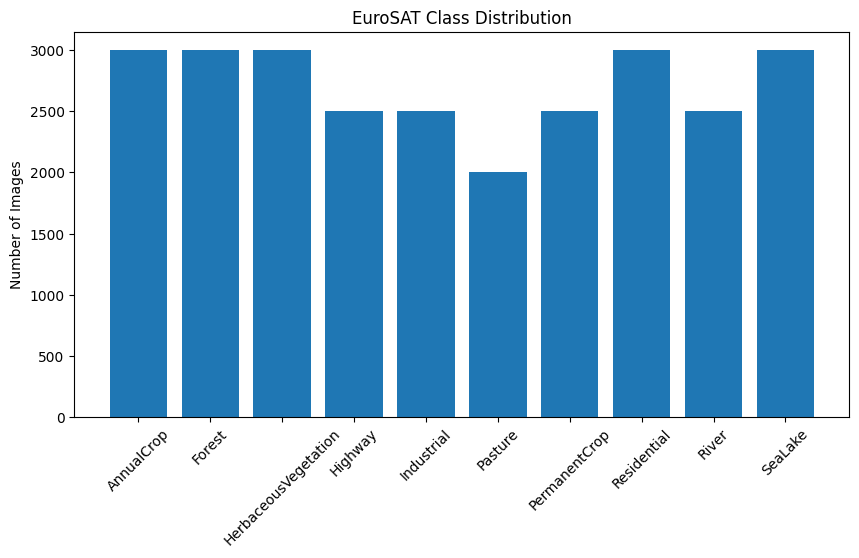

In [18]:
#EuroSAT Distributions
import os
dataset_path = "/content/2750"

classes = []
counts = []

for folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        classes.append(folder)
        counts.append(len(os.listdir(folder_path)))

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.title("EuroSAT Class Distribution")
plt.show()

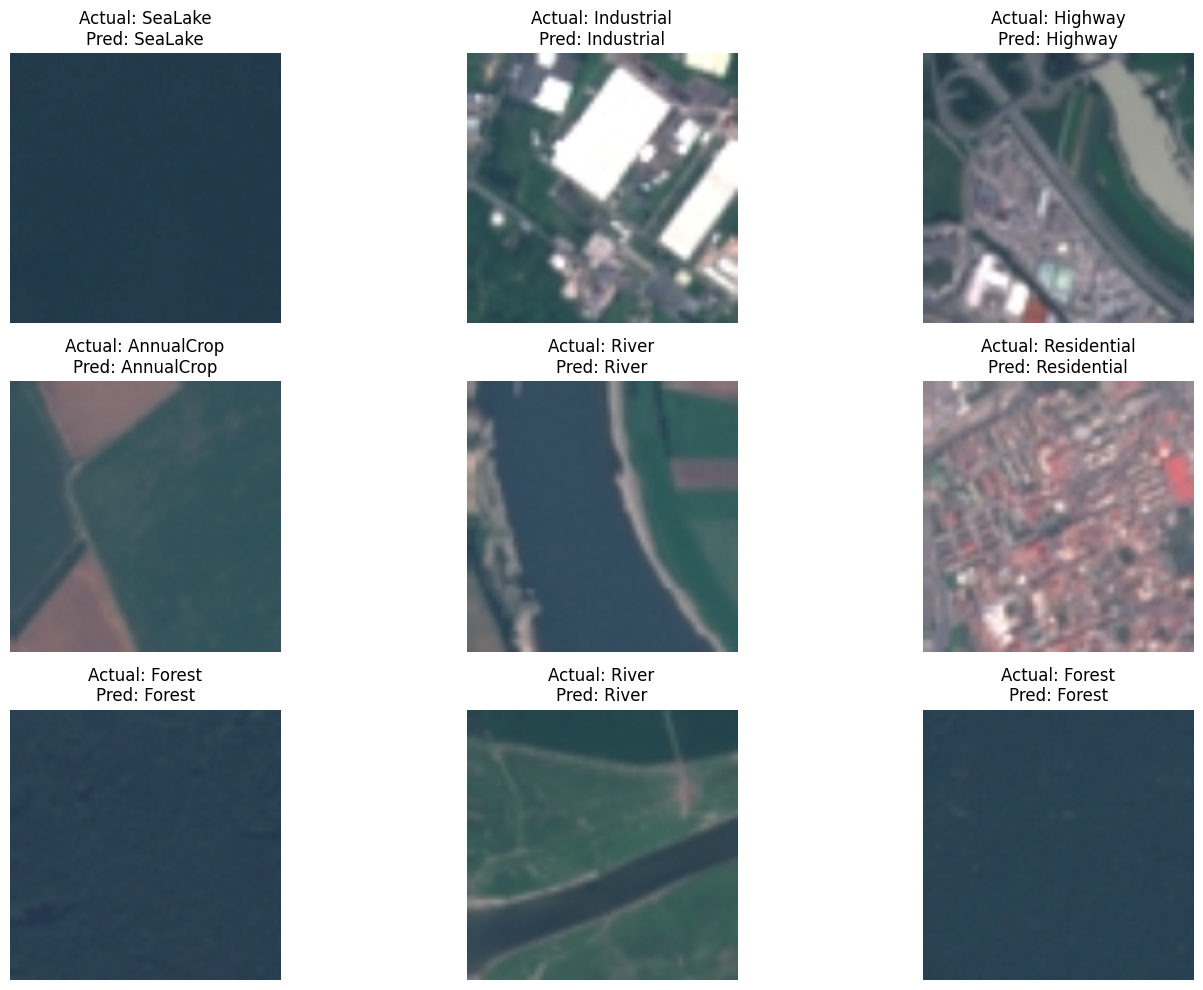

In [19]:
#Model Evalution 1.
import numpy as np

model.eval()

fig = plt.figure(figsize=(15, 10))

for i in range(9):
    image, label = test_dataset[i]

    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_image)
        _, prediction = torch.max(output, 1)

    # Undo normalization
    img = image.permute(1, 2, 0)
    img = img * torch.tensor(std) + torch.tensor(mean)
    img = img.clamp(0, 1)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"Actual: {dataset.classes[label]}\nPred: {dataset.classes[prediction.item()]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

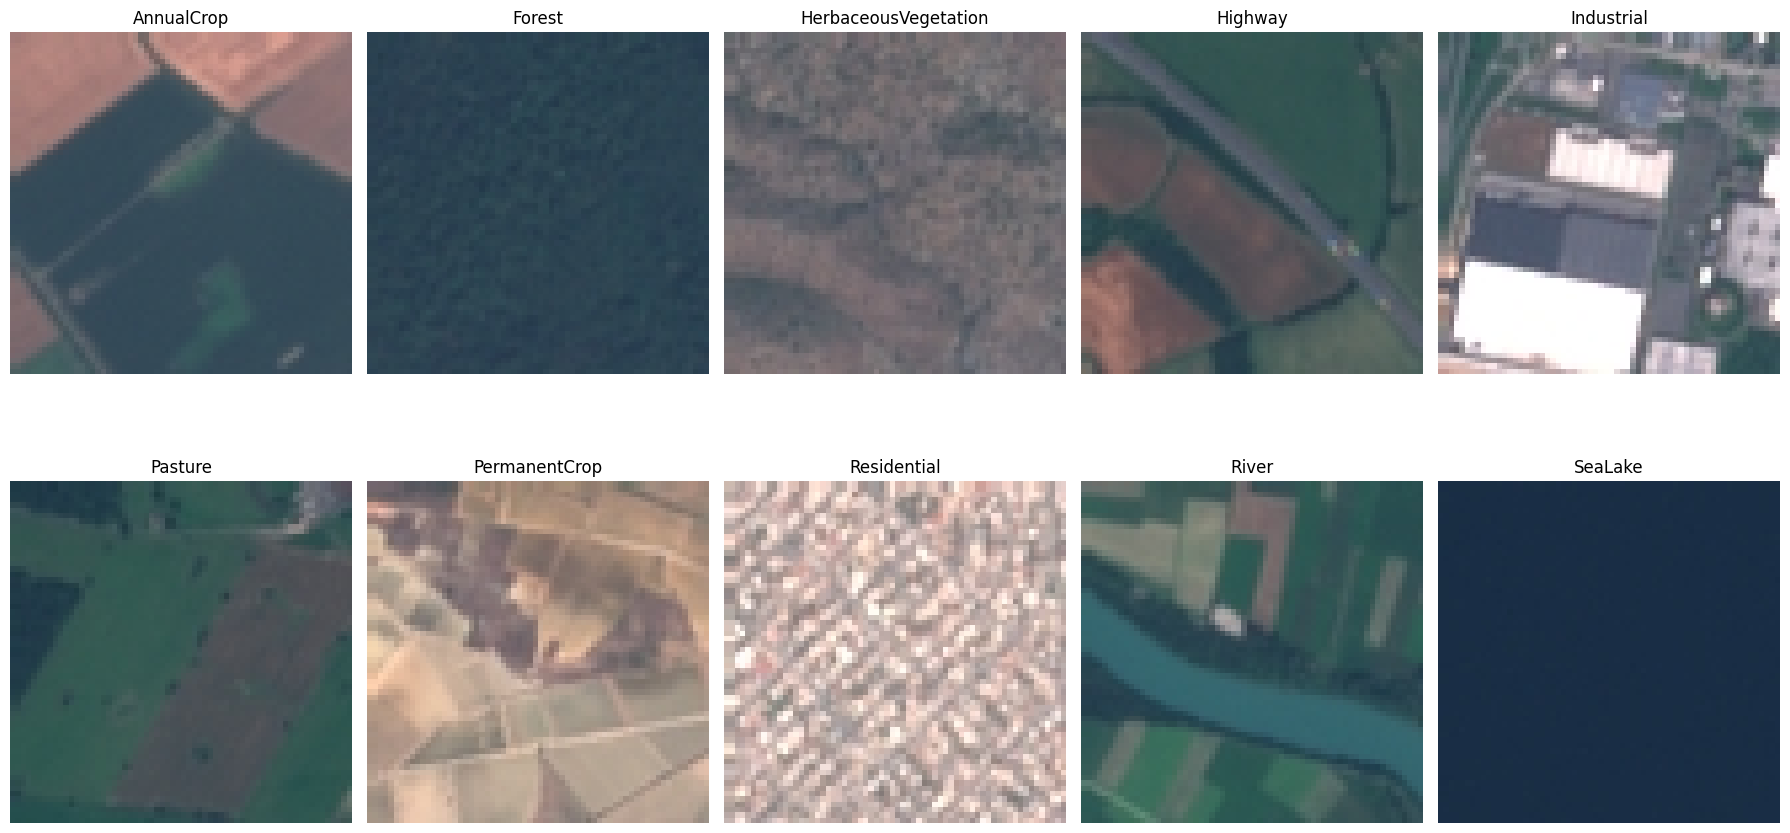

In [20]:
#Model Evalution 2.
import random
import os
from PIL import Image

dataset_path = "/content/2750"

classes = sorted(os.listdir(dataset_path))

plt.figure(figsize=(18,10))

for i, cls in enumerate(classes):
    img_path = random.choice(os.listdir(os.path.join(dataset_path, cls)))
    image = Image.open(os.path.join(dataset_path, cls, img_path))

    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
#Regarding the Image Sizes
from PIL import Image
import os

dataset_path = "/content/2750"

sizes = []

for cls in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, cls)

    if os.path.isdir(folder):
        img = os.listdir(folder)[0]
        image = Image.open(os.path.join(folder, img))
        sizes.append(image.size)

print("Unique Image Sizes:")
print(set(sizes))

Unique Image Sizes:
{(64, 64)}


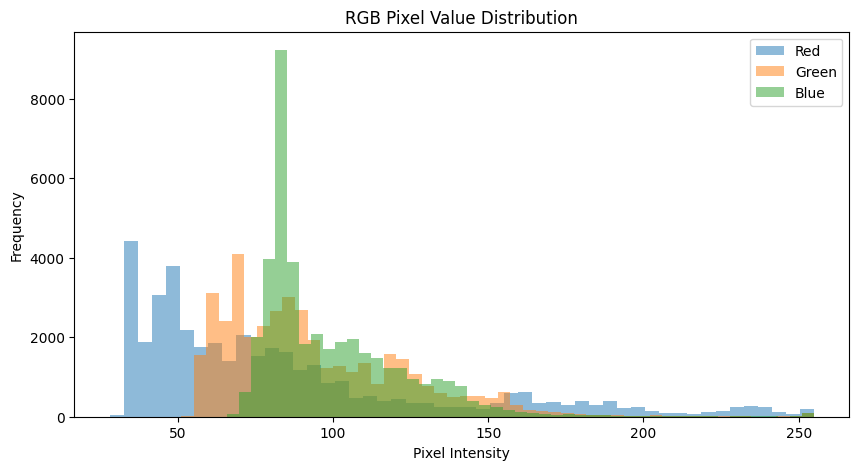

In [22]:
#Distribution of Pixel Value Across RGB Channel
dataset_path = "/content/2750"

r, g, b = [], [], []

for cls in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, cls)

    if os.path.isdir(folder):
        img_name = random.choice(os.listdir(folder))
        img = np.array(Image.open(os.path.join(folder, img_name)))

        r.extend(img[:,:,0].flatten())
        g.extend(img[:,:,1].flatten())
        b.extend(img[:,:,2].flatten())

plt.figure(figsize=(10,5))
plt.hist(r, bins=50, alpha=0.5, label="Red")
plt.hist(g, bins=50, alpha=0.5, label="Green")
plt.hist(b, bins=50, alpha=0.5, label="Blue")
plt.title("RGB Pixel Value Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

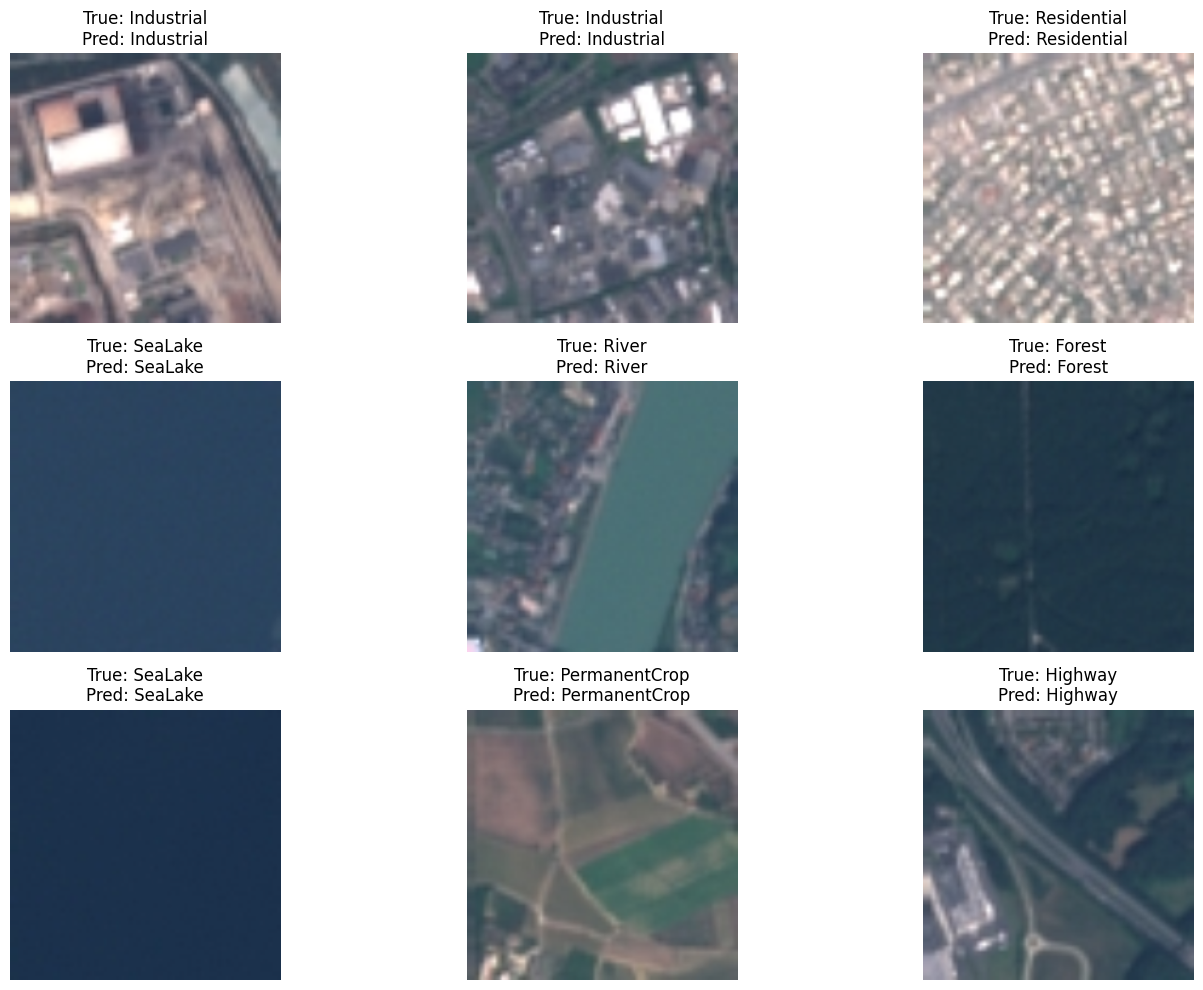

In [23]:
#Model Evalution 3.
model.eval()

indices = random.sample(range(len(test_dataset)), 9)

plt.figure(figsize=(15,10))

for i, idx in enumerate(indices):
    image, label = test_dataset[idx]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        pred = output.argmax(1).item()

    img = image.permute(1,2,0)
    img = img * torch.tensor(std) + torch.tensor(mean)
    img = img.clamp(0,1)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(
        f"True: {dataset.classes[label]}\nPred: {dataset.classes[pred]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

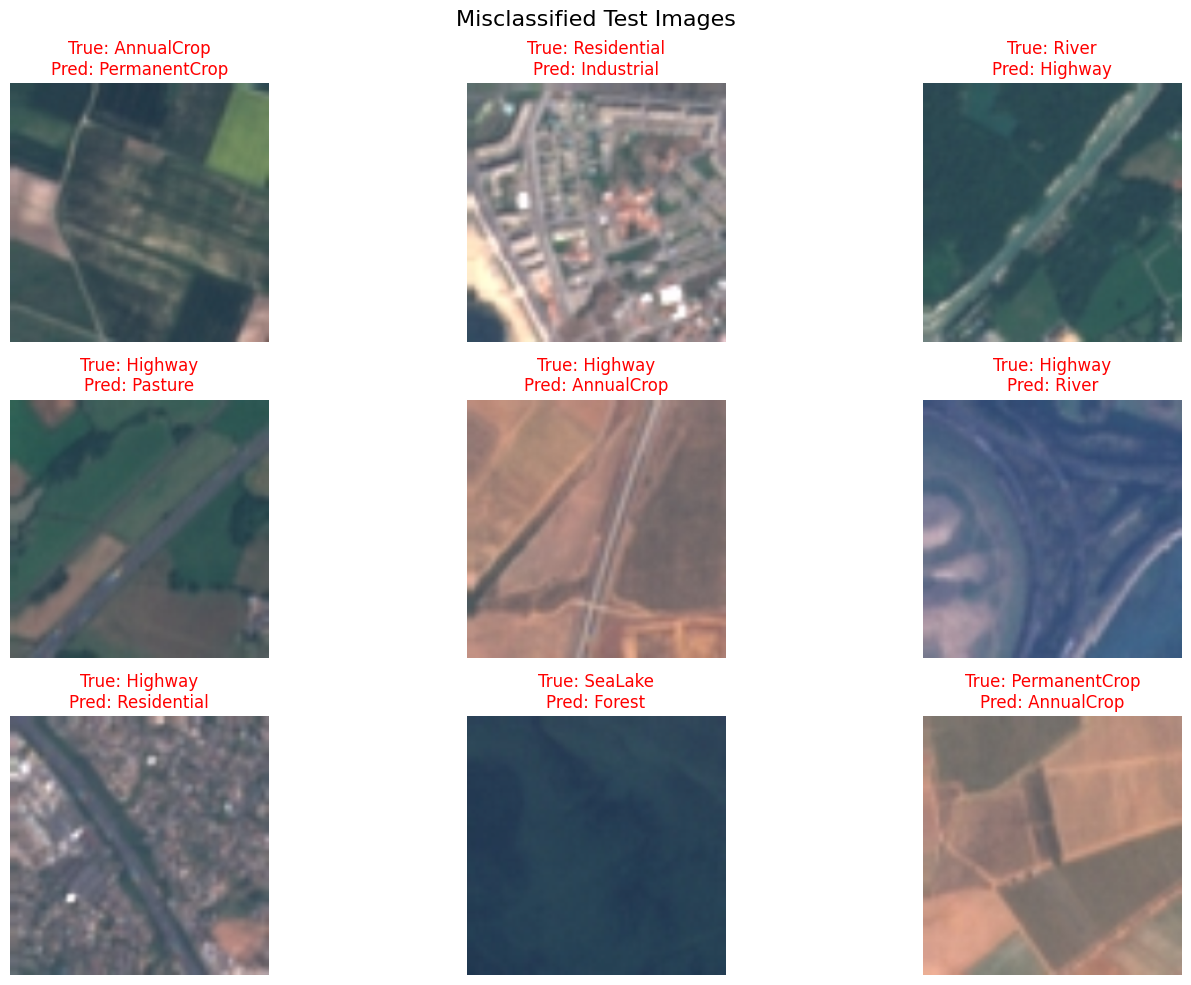

Total Misclassified Images: 170


In [24]:
#Top 10 missclassified Images
model.eval()

misclassified_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified_images.append((
                    images[i].cpu(),
                    labels[i].cpu().item(),
                    preds[i].cpu().item()
                ))

# Show first 9 misclassified images
plt.figure(figsize=(15,10))

for i in range(min(9, len(misclassified_images))):
    image, true_label, pred_label = misclassified_images[i]

    # Undo normalization
    image = image.permute(1,2,0)
    image = image * torch.tensor(std) + torch.tensor(mean)
    image = image.clamp(0,1)

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(
        f"True: {dataset.classes[true_label]}\nPred: {dataset.classes[pred_label]}",
        color="red"
    )
    plt.axis("off")

plt.suptitle("Misclassified Test Images", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Total Misclassified Images: {len(misclassified_images)}")

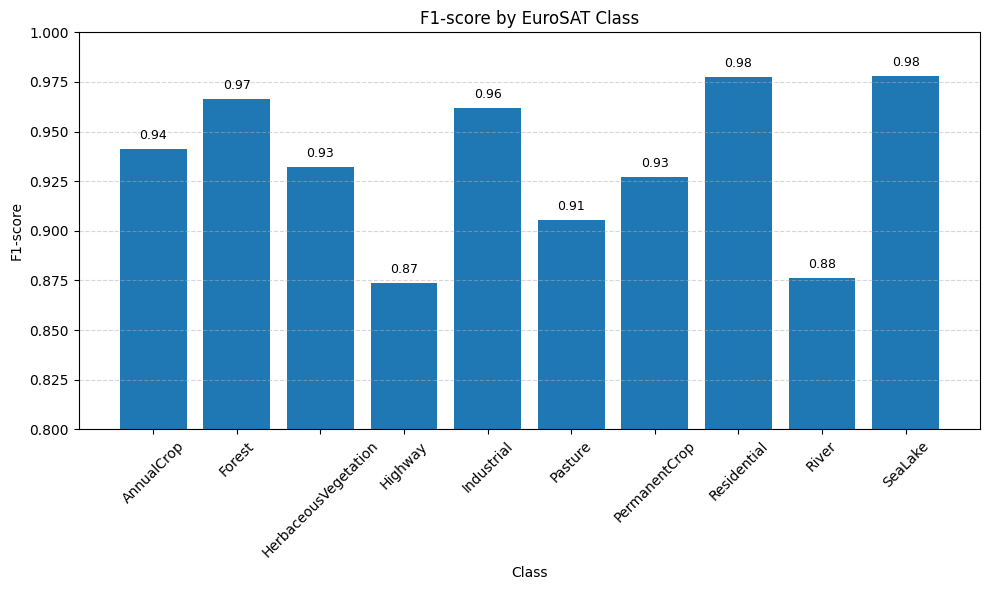

In [25]:
#F1-Score by EuroSAT Class
from sklearn.metrics import classification_report
import torch
import numpy as np

# Ensure model is in evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

report = classification_report( all_labels, all_preds, target_names=dataset.classes, output_dict=True )

classes = dataset.classes
f1_scores = [report[c]["f1-score"] for c in classes]

plt.figure(figsize=(10,6))
bars = plt.bar(classes, f1_scores)

plt.ylim(0.8, 1.0)
plt.ylabel("F1-score")
plt.xlabel("Class")
plt.title("F1-score by EuroSAT Class")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.2f}", ha="center", fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Conclusion

In this project, a pretrained ResNet50 model was fine-tuned using the EuroSAT dataset for land cover classification.

Results:

- Test Accuracy: 94.81%
- Weighted F1-score: 0.95
- Dataset: 27,000 RGB Images
- Classes: 10

The model achieved strong generalization performance and successfully classified satellite images into ten land-cover categories using transfer learning.

Future Improvements

• Fine-tune deeper layers

• Train for more epochs

• Compare with EfficientNet

• Use Data Augmentation

• Deploy using Streamlit